# LDPC: ver la misma estructura en una matriz y en un grafo

**Tema 3 · Apartados 3.5 · Demostración orientativa: 8–15 minutos.**

Reconocer qué bits intervienen en cada comprobación y distinguir el número de filas del número de restricciones independientes.

## Cómo experimentar

Ejecuta todo de arriba abajo. Cambia un parámetro, predice qué ocurrirá
y vuelve a ejecutar todas las celdas. En Jupyter: *Kernel → Restart Kernel and Run All Cells*;
en Colab: *Entorno de ejecución → Ejecutar todas*.

La vista HTML muestra los resultados guardados. Para recalcular se utiliza este cuaderno.
Los comentarios `#@param` permiten formularios en Colab; en Jupyter puedes editar los valores.
No se necesitan datos externos ni otros cuadernos. Las figuras y cálculos son deterministas.

## Modelo y pregunta

Partimos de la matriz de cinco filas y diez columnas de la teoría. Cada columna representa
un bit y cada fila una comprobación de paridad. Un 1 en la posición $(j,i)$ se convierte
en una arista entre la comprobación $f_j$ y la variable $v_i$.

Cada columna de la matriz original tiene dos unos. Por tanto, al sumar todas las filas
módulo 2 obtenemos cero: la quinta fila se puede obtener sumando las cuatro primeras.
Estas cuatro son independientes (las columnas 4, 7, 9 y 10 forman una identidad en ellas).
Así, el rango binario es 4 y **k = 10 − 4 = 6**, aunque haya cinco filas.

Se pueden elegir tres representaciones del mismo código: la original, las cuatro primeras
filas o la original con su primera fila repetida. En todas, el rango sigue siendo 4.
No calculamos síndromes ni ejecutamos un algoritmo de decodificación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## Parámetros

Modifica un valor cada vez. Los comentarios indican unidades y rangos.

In [2]:
#@title Parámetros
representacion = "original" #@param ["original", "cuatro_filas", "fila_repetida"]
fila = 1 #@param {type:"integer"}
variable = 1 #@param {type:"integer"}
mostrar_ciclo = True #@param {type:"boolean"}
# Fila: 1–5, 1–4 o 1–6, según la representación; variable: 1–10.
assert representacion in ["original","cuatro_filas","fila_repetida"]
assert isinstance(fila,int) and isinstance(variable,int) and 1 <= variable <= 10

## 1. Matriz y grafo, lado a lado

La fila elegida se destaca en naranja y la variable en azul verdoso. Sigue sus conexiones
y comprueba que cada arista equivale a un 1. Los cruces de líneas **no son nodos**.
La matriz es pequeña para poder dibujarla; no pretende representar la densidad de un LDPC largo.

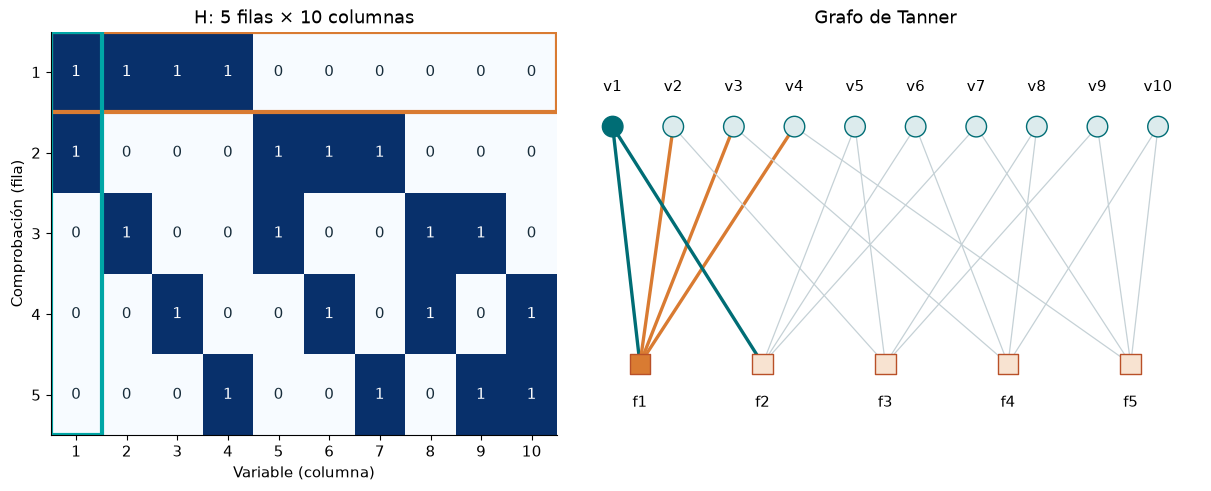

Grados de variables: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]; grados de comprobaciones: [4, 4, 4, 4, 4].
Unos = 20; densidad = 0.400; rango = 4; k = 6.


In [3]:
from matplotlib.patches import Rectangle
H_original = np.array([
    [1,1,1,1,0,0,0,0,0,0],
    [1,0,0,0,1,1,1,0,0,0],
    [0,1,0,0,1,0,0,1,1,0],
    [0,0,1,0,0,1,0,1,0,1],
    [0,0,0,1,0,0,1,0,1,1]],dtype=int)
H = {"original":H_original,"cuatro_filas":H_original[:4],
     "fila_repetida":np.vstack([H_original,H_original[0]])}[representacion]
m,n = H.shape
assert 1 <= fila <= m, f"La fila debe estar entre 1 y {m}."
grados_variables = H.sum(axis=0)
grados_comprobaciones = H.sum(axis=1)
rango = 4  # Justificado en el modelo para estas tres matrices concretas.
fig,(ax,grafo) = plt.subplots(1,2,figsize=(12,4.8),layout="constrained",gridspec_kw={"width_ratios":[1,1.25]})
ax.imshow(H,cmap="Blues",vmin=0,vmax=1,aspect="auto")
for j in range(m):
    for i in range(n):
        ax.text(i,j,str(H[j,i]),ha="center",va="center",color="white" if H[j,i] else "#172c3a")
ax.add_patch(Rectangle((-.5,fila-1.5),n,1,fill=False,edgecolor="#d97b32",lw=3))
ax.add_patch(Rectangle((variable-1.5,-.5),1,m,fill=False,edgecolor="#00a6a6",lw=3))
ax.set(xticks=range(n),xticklabels=range(1,n+1),yticks=range(m),yticklabels=range(1,m+1),
       xlabel="Variable (columna)",ylabel="Comprobación (fila)",title=f"H: {m} filas × {n} columnas")
xv = np.linspace(0,1,n)
xf = np.linspace(.05,.95,m)
for j,i in np.argwhere(H):
    color,grosor = "#c5d1d6",.9
    if j == fila-1: color,grosor = "#d97b32",2.4
    if i == variable-1: color,grosor = "#006d75",2.4
    grafo.plot([xv[i],xf[j]],[1,0],color=color,lw=grosor,zorder=1)
grafo.scatter(xv,np.ones(n),s=220,c=["#006d75" if i==variable-1 else "#dcebed" for i in range(n)],edgecolor="#006d75",zorder=3)
grafo.scatter(xf,np.zeros(m),s=220,marker="s",c=["#d97b32" if j==fila-1 else "#f8e3d1" for j in range(m)],edgecolor="#b95028",zorder=3)
for i,x in enumerate(xv): grafo.text(x,1.15,f"v{i+1}",ha="center")
for j,x in enumerate(xf): grafo.text(x,-.18,f"f{j+1}",ha="center")
grafo.set(xlim=(-.08,1.08),ylim=(-.3,1.4),title="Grafo de Tanner")
grafo.axis("off"); plt.show()
print(f"Grados de variables: {grados_variables.tolist()}; grados de comprobaciones: {grados_comprobaciones.tolist()}.")
print(f"Unos = {H.sum()}; densidad = {H.mean():.3f}; rango = {rango}; k = {n-rango}.")

## 2. Un ciclo de longitud cuatro

Existe cuando dos comprobaciones comparten dos variables. Se recorren cuatro aristas
y se vuelve al nodo inicial. El siguiente bloque solo **busca y dibuja conexiones**.

Prueba `fila_repetida`. Repetir una restricción no aporta información independiente,
pero sí modifica el grafo y crea ciclos cortos. En decodificación iterativa, los ciclos
favorecen que la información vuelva pronto a su origen; este dibujo no mide la BER.
Que no haya ciclos de longitud cuatro **no significa que no haya ciclos de otras longitudes**.

In [4]:
from itertools import combinations
ciclos = []
for j,k in combinations(range(m),2):
    comunes = np.flatnonzero((H[j] == 1) & (H[k] == 1))
    for i,l in combinations(comunes,2):
        ciclos.append((j,k,int(i),int(l)))
print(f"Ciclos distintos de longitud cuatro: {len(ciclos)}.")
if mostrar_ciclo and ciclos:
    j,k,i,l = ciclos[0]
    fig,ax = plt.subplots(figsize=(6,3.5),layout="constrained")
    for x1 in [0,1]:
        for x2 in [0,1]: ax.plot([x1,x2],[1,0],color="#b95028",lw=2)
    ax.scatter([0,1],[1,1],s=350,color="#dcebed",edgecolor="#006d75",zorder=3)
    ax.scatter([0,1],[0,0],s=350,marker="s",color="#f8e3d1",edgecolor="#b95028",zorder=3)
    for x,label in enumerate([f"v{i+1}",f"v{l+1}"]): ax.text(x,1.15,label,ha="center")
    for x,label in enumerate([f"f{j+1}",f"f{k+1}"]): ax.text(x,-.2,label,ha="center")
    ax.set(xlim=(-.3,1.3),ylim=(-.35,1.4),title=f"Recorrido: v{i+1} → f{j+1} → v{l+1} → f{k+1} → v{i+1}")
    ax.axis("off"); plt.show()
elif mostrar_ciclo:
    print("No hay ciclos de longitud cuatro. Prueba la representación fila_repetida.")

Ciclos distintos de longitud cuatro: 0.
No hay ciclos de longitud cuatro. Prueba la representación fila_repetida.


## Antes de mirar la explicación

1. ¿Cuántas aristas salen de una variable y de una comprobación en la matriz original?
2. Elimina la quinta fila con cuatro_filas: ¿por qué no cambia k?
3. Elige fila_repetida: ¿aumenta la redundancia transmitida por añadir esa fila?
4. ¿Una mayor cantidad de filas o una menor densidad garantiza por sí sola mejor BER?

## Explicación de lo observado

1. Dos por variable y cuatro por comprobación: es el ejemplo regular $(J,K)=(2,4)$.
   En las otras representaciones los grados de las variables ya no son todos iguales.
2. La quinta fila es la suma módulo 2 de las otras cuatro. El conjunto de palabras
   que satisface las comprobaciones no cambia; sigue habiendo cuatro restricciones independientes.
3. No. Siguen siendo n = 10 y k = 6, con cuatro bits redundantes por palabra.
   La fila repetida cambia el grafo, pero no las palabras permitidas ni la tasa del código.
   Aparecen seis ciclos de longitud cuatro porque las dos filas idénticas comparten cuatro variables.
4. No. Importan la estructura, las dependencias, los ciclos, la longitud y el algoritmo.
   Este ejemplo explica la representación; no evalúa las prestaciones de un decodificador.

## Comprobación del modelo

Comprobamos identidades y casos conocidos; estas celdas no sustituyen la interpretación.

In [5]:
assert np.array_equal(H_original.sum(axis=0)%2,np.zeros(10,dtype=int))
assert np.array_equal(H_original[:4,[3,6,8,9]],np.eye(4,dtype=int))
assert grados_variables.sum() == grados_comprobaciones.sum() == H.sum()
assert len(ciclos) == (6 if representacion == "fila_repetida" else 0)
print("Dependencia de filas, rango y ciclos contrastados con la estructura conocida.")

Dependencia de filas, rango y ciclos contrastados con la estructura conocida.


## Referencias

Ejemplo y código propios para TDI.

- TDI, tema 3, apartados 3.5: «Ejemplo de matriz regular: diez variables», «Por qué algunas matrices H son cuadradas» y «Grafos de Tanner».
- J. G. Proakis y M. Salehi, *Digital Communications*, 5.ª ed., McGraw-Hill, 2008: codificación de canal.
- Los supuestos y las derivaciones particulares de este experimento se explican en «Modelo y pregunta».